# **Activity 3.3: Clustering: Analyzing Air Quality with K-Means**

In this notebook, you’ll explore how **K-Means Clustering** works by analyzing air quality data collected from different neighborhoods. This activity will help you understand:

1. How to visualize data for clustering.
2. How K-Means algorithm groups data points into clusters.
3. How to interpret and use the results to uncover patterns.

We’ll use Python libraries such as `pandas`, `matplotlib`, and `sklearn` to complete this activity.

## **Step 1: Import Libraries and Define the Dataset**

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Define the dataset
data = {
    'Neighborhood': ['Downtown', 'Riverside', 'Suburb A', 'Suburb B',
                     'Industrial Zone', 'Midtown', 'Uptown', 'Lakeside',
                     'Old Town', 'City Park'],
    'X': [3, 2, 9, 10, 1, 3, 8, 9, 4, 6],
    'Y': [8, 7, 6, 7, 2, 3, 9, 8, 5, 4],
    'PM2.5': [56, 45, 30, 25, 85, 50, 35, 40, 60, 28]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display the dataset
print("Dataset:\n", df)

ModuleNotFoundError: No module named 'matplotlib'

## **Step 2: Visualize the Data**

### Scatter Plot
We’ll create a scatter plot to visualize the neighborhoods by their `(X, Y)` coordinates. This will help us see natural groupings and prepare for clustering.

In [2]:
# Scatter plot of neighborhoods
plt.figure(figsize=(8, 6))
plt.scatter(df['X'], df['Y'], s=100, c='blue', label='Neighborhoods')
for i, txt in enumerate(df['Neighborhood']):
    plt.annotate(txt, (df['X'][i], df['Y'][i]), fontsize=9, xytext=(5, -5), textcoords='offset points')
plt.title('Neighborhoods by Coordinates')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid()
plt.show()

NameError: name 'plt' is not defined

### **Reflection Questions**
- **Q1**: What patterns or natural groupings do you observe in the scatter plot?
- **Q2**: Are there any outliers or points that seem far from the rest? Which ones?

## **Step 3: Apply K-Means Clustering**

Now, we’ll use the `KMeans` algorithm from the `sklearn` library to group the neighborhoods into clusters based on their coordinates.

In [3]:
# Prepare data for clustering
X = df[['X', 'Y']].values  # Use coordinates for clustering

# Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)  # Set 3 clusters
kmeans.fit(X)

# Add cluster labels to the DataFrame
df['Cluster'] = kmeans.labels_

# Display the clustered dataset
print("\nClustered Dataset:\n", df)


Clustered Dataset:
       Neighborhood   X  Y  PM2.5  Cluster
0         Downtown   3  8     56        2
1        Riverside   2  7     45        2
2         Suburb A   9  6     30        0
3         Suburb B  10  7     25        0
4  Industrial Zone   1  2     85        1
5          Midtown   3  3     50        1
6           Uptown   8  9     35        0
7         Lakeside   9  8     40        0
8         Old Town   4  5     60        1
9        City Park   6  4     28        1


### **Explanation of Key Code**
- **`KMeans(n_clusters=3)`**: Tells the algorithm to form 3 clusters.
- **`fit()`**: Runs the K-Means algorithm on the data.
- **Cluster Labels**: Each point is assigned a cluster label (e.g., 0, 1, or 2).

## **Step 4: Visualize the Clusters**

We’ll plot the clustered points with different colors for each cluster. The centroids (cluster centers) will be marked with yellow "X" symbols.

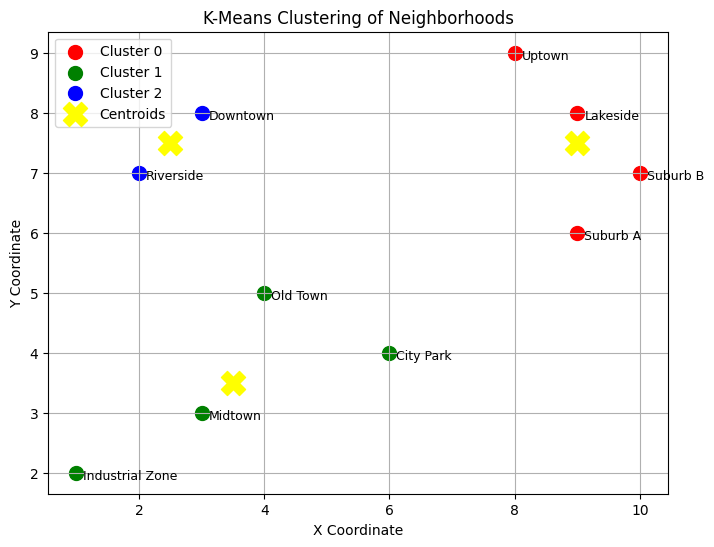

In [4]:
# Visualize clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for cluster in range(3):
    cluster_points = df[df['Cluster'] == cluster]
    plt.scatter(cluster_points['X'], cluster_points['Y'],
                s=100, label=f'Cluster {cluster}', color=colors[cluster])

# Annotate neighborhoods
for i, txt in enumerate(df['Neighborhood']):
    plt.annotate(txt, (df['X'][i], df['Y'][i]), fontsize=9, xytext=(5, -5), textcoords='offset points')

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', marker='X', label='Centroids')

plt.title('K-Means Clustering of Neighborhoods')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid()
plt.show()

### **Reflection Questions**
- **Q3**: How are the clusters distributed? Do they align with the natural groupings you observed earlier?
- **Q4**: How do the centroids represent the "center" of each cluster?

## **Stretch Goal: Include PM2.5 Levels in Clustering**

You can extend the model by including pollution levels (PM2.5) as a feature. This will help K-Means consider both spatial location and air quality in its clustering decisions.

In [5]:
# Clustering with PM2.5 levels included
X_extended = df[['X', 'Y', 'PM2.5']].values
kmeans_with_pm25 = KMeans(n_clusters=3, random_state=42)
kmeans_with_pm25.fit(X_extended)

# Add new cluster labels
df['Cluster_with_PM2.5'] = kmeans_with_pm25.labels_

# Display updated dataset
print("\nClustered Dataset with PM2.5:\n", df)


Clustered Dataset with PM2.5:
       Neighborhood   X  Y  PM2.5  Cluster  Cluster_with_PM2.5
0         Downtown   3  8     56        2                   2
1        Riverside   2  7     45        2                   2
2         Suburb A   9  6     30        0                   0
3         Suburb B  10  7     25        0                   0
4  Industrial Zone   1  2     85        1                   1
5          Midtown   3  3     50        1                   2
6           Uptown   8  9     35        0                   0
7         Lakeside   9  8     40        0                   0
8         Old Town   4  5     60        1                   2
9        City Park   6  4     28        1                   0


### **Reflection Questions**
- **Q5**: How do the clusters change when PM2.5 is included?
- **Q6**: Which neighborhoods are grouped differently, and why?

## **Key Takeaways**

1. **Clustering Reveals Patterns**: K-Means helps uncover natural groupings in data.
2. **Centroids Are Key**: Centroids represent the center of each cluster and influence cluster boundaries.
3. **Adding Features Refines Insights**: Including more features, like pollution levels, enhances clustering outcomes.

Great job exploring clustering with K-Means! 🚀